# Project Notebook - Matteo Sgobba | Entry Point

This notebook is organized in sequential sections:

1. Data exploration (development/evaluation)
2. Common preprocessing and feature construction
3. Model selection / hyperparameter tuning:
   - Logistic Regression (word TF-IDF)
   - LinearSVC (word + character TF-IDF) --> **best model**
   - SGDClassifier baseline
   - Dummy naive solution
   - Intermediate predictions construction
4. Final training and prediction for submissions

__NOTES:__
- After the shared preprocessing, each model has its own preprocessing pipeline. Each section is self-contained and can be executed in order.
- Full hyperparameter tuning may be time-consuming; tuning outputs are included.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [2]:
df = pd.read_csv("development.csv")
eval = pd.read_csv("evaluation.csv")

# 1) Data Exploration

In [3]:
print("Train shape: ", df.shape)
print("Evalation shape: ", eval.shape)

Train shape:  (79997, 7)
Evalation shape:  (20000, 6)


In [4]:
print("Train columns:", df.columns.tolist())
print("Evaluation columns:", eval.columns.tolist())

Train columns: ['Id', 'source', 'title', 'article', 'page_rank', 'timestamp', 'label']
Evaluation columns: ['Id', 'source', 'title', 'article', 'page_rank', 'timestamp']


Columns match perfectly, so we are good.

## Missing values and placeholders

__Missing values and placeholders:__ Let's have a look at the missing values:

In [5]:
print("Missing values rate for train:\n", df.isna().mean().sort_values(ascending=False)*100)
print("Missing values rate for evaluation:\n", eval.isna().mean().sort_values(ascending=False)*100)

Missing values rate for train:
 title        0.00125
article      0.00125
Id           0.00000
source       0.00000
page_rank    0.00000
timestamp    0.00000
label        0.00000
dtype: float64
Missing values rate for evaluation:
 article      0.005
Id           0.000
source       0.000
title        0.000
page_rank    0.000
timestamp    0.000
dtype: float64


Appearently, there are no missing values in both dataset, just a negligible percentage of missing values for the "title" and "article" columns.

In [6]:
df["ts_missing"] = (df["timestamp"] == "0000-00-00 00:00:00")
eval["ts_missing"] = (eval["timestamp"] == "0000-00-00 00:00:00")

In [7]:
print("Timestamp placeholder rate DEV:", df["ts_missing"].mean())
print("Timestamp placeholder rate EVA:", eval["ts_missing"].mean())

Timestamp placeholder rate DEV: 0.34688800830031125
Timestamp placeholder rate EVA: 0.34905


One thing we can check is that if there are any placeholder timestamps:

In [8]:
df["ts_parsed"] = pd.to_datetime(df["timestamp"].where(~df["ts_missing"]), errors="coerce")
print("Parsed timestamp range: ", df["ts_parsed"].min(), "->", df["ts_parsed"].max())

Parsed timestamp range:  2004-08-18 02:45:46 -> 2008-02-20 21:52:30


### Missing timestamps, by label

In [9]:
tsmiss_by_label = df.groupby("label")["ts_missing"].mean()
print("Timestamp-missing rate by label:\n", tsmiss_by_label.round(4))

Timestamp-missing rate by label:
 label
0    0.3456
1    0.3104
2    0.2207
3    0.4052
4    0.4348
5    0.3768
6    0.3791
Name: ts_missing, dtype: float64


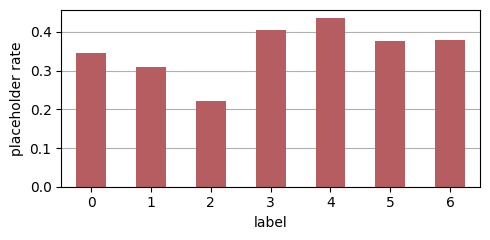

In [10]:
plt.figure(figsize=(5, 2.5))

sns.barplot(x=tsmiss_by_label.sort_index().index, y=tsmiss_by_label.sort_index().values, width=0.5, color="#C44E52")
# plt.title("Timestamp placeholder rate by label")
plt.xlabel("label")
plt.ylabel("placeholder rate")
plt.gca().set_axisbelow(True)
plt.grid(axis="y")
plt.tight_layout()
#plt.savefig("timestamp_placeholder_rate.pdf", bbox_inches="tight")
plt.show()

In [11]:
# (Plot not present in the report)

## Label Distribution

__Label distribution:__ here we are analyzing the label distribution in our dataset.

In [12]:
label_counts = df.iloc[:, -3].value_counts(normalize=True)
label_counts

label
0    0.294286
5    0.163169
2    0.139518
1    0.132355
3    0.124717
4    0.107179
6    0.038776
Name: proportion, dtype: float64

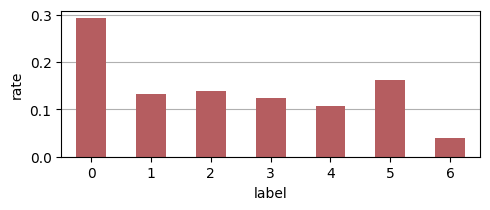

In [13]:
plt.figure(figsize=(5, 2.2))

sns.barplot(x=label_counts.index, y=label_counts.values, width=0.5, color="#C44E52")
# plt.title("Label distribution")
plt.xlabel("label")
plt.ylabel("rate")
plt.gca().set_axisbelow(True)
plt.grid(axis="y")
plt.tight_layout()
#plt.savefig("label_distribution.pdf", bbox_inches="tight")
plt.show()

The presence of a low-frequency class negatively affect macro-F1 because, with this metric, each class contributes equally to the final score. Rare classes are harder to learn due to limited training examples, leading to low precision or recall.

## Source exploration

In [14]:
print("Number of sources TRAIN:", df["source"].nunique())
print("Number of sources EVAL:", eval["source"].nunique())

top_sources = df["source"].value_counts().head(15)
print("\nTop sources (TRAIN):\n", top_sources)

# Sources in eval not seen in development
unseen = set(eval["source"].unique()) - set(df["source"].unique())
print("\nUnseen sources in EVA:", len(unseen))
print("Examples:", list(unseen)[:20])

# Label distribution for top sources
top_src_names = top_sources.index.tolist()[:8]
src_label = df[df["source"].isin(top_src_names)].groupby(["source","label"]).size().unstack(fill_value=0)
src_label_pct = src_label.div(src_label.sum(axis=1), axis=0)

print("\nLabel counts within top sources:\n", src_label)
print("\nLabel % within top sources:\n", src_label_pct.round(3))

Number of sources TRAIN: 1359
Number of sources EVAL: 797

Top sources (TRAIN):
 source
Yahoo            15850
Reuters          11915
BBC               7971
New               6430
Washington        3383
RedNova           2701
Boston            1807
CNN               1802
CNET              1369
Topix.Net         1331
Guardian          1011
Motley             931
Register           834
International      756
Forbes             720
Name: count, dtype: int64

Unseen sources in EVA: 116
Examples: ['Communications', 'BPM', 'Elizabethtown', 'I.T.', 'Parkersburg', 'WOI', 'Bend.com', 'Mattoon', 'Pottstown', 'Annapolis', 'BoxingTalk', 'Galveston', 'Drug', 'Pahrump', 'Blabbermouth.net', 'Mariners.org', 'Hamptons', 'WGRZ-TV', 'ITBusiness.ca', 'Reno']

Label counts within top sources:
 label          0     1     2     3     4     5    6
source                                             
BBC         4401   468   190   404    69  2220  219
Boston       428   464    12    81   726    88    8
CNN     

## Text length exploration

In [15]:
# Function for word-counting

def word_count(s):
    if pd.isna(s):
        return 0
    return len(re.findall(r"\b\w+\b", str(s)))


Title word-count:
 count    79997.000000
mean         7.221921
std          2.359670
min          0.000000
50%          7.000000
75%          8.000000
90%         10.000000
95%         11.000000
99%         14.000000
max         47.000000
Name: title_wc, dtype: float64

Article word-count:
 count    79997.000000
mean        45.506819
std         58.553520
min          0.000000
50%         32.000000
75%         40.000000
90%        119.000000
95%        148.000000
99%        198.000000
max       2545.000000
Name: article_wc, dtype: float64

Per-label text length summary:
        title_wc                         article_wc                          
           mean median       std  count       mean median         std  count
label                                                                       
0      7.364540    7.0  2.170228  23542  49.528715   33.0   45.397762  23542
1      7.084152    7.0  2.245700  10588  34.661598   31.0   26.582262  10588
2      7.581220    7.0  3.036555  11

C:\Users\matte\AppData\Local\Temp\ipykernel_15740\2746334668.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outliers_df = (df.groupby("label", group_keys=False).apply(extract_outliers))


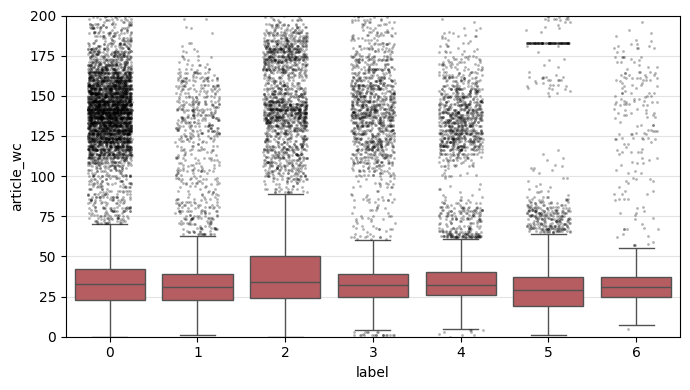

In [16]:
import re

df["title_wc"] = df["title"].map(word_count)
df["article_wc"] = df["article"].map(word_count)

print("\nTitle word-count:\n", df["title_wc"].describe(percentiles=[.5,.75,.9,.95,.99]))
print("\nArticle word-count:\n", df["article_wc"].describe(percentiles=[.5,.75,.9,.95,.99]))

# Per-label lengths
per_label_len = df.groupby("label")[["title_wc","article_wc"]].agg(["mean","median","std","count"])
print("\nPer-label text length summary:\n", per_label_len)

# Boxplot
def extract_outliers(group):
    q1 = group["article_wc"].quantile(0.25)
    q3 = group["article_wc"].quantile(0.75)
    iqr = q3 - q1
    return group[(group["article_wc"] < q1 - 1.5 * iqr) | (group["article_wc"] > q3 + 1.5 * iqr)]

outliers_df = (df.groupby("label", group_keys=False).apply(extract_outliers))

fig, ax = plt.subplots(figsize=(7, 4))

ax.set_axisbelow(True)
ax.grid(True, which="major", axis="y", linestyle="-", alpha=0.35)
ax.grid(True, which="major", axis="x", linestyle=":",  alpha=0.15)
sns.boxplot(data=df, x="label", y="article_wc", showfliers=False, color="#C44E52")
sns.stripplot(data=outliers_df, x="label", y="article_wc", jitter=0.25, size=2, alpha=0.3, color="black")
plt.ylim(0, 200)
#plt.title("Article word-count by label")
plt.tight_layout()
#plt.savefig("boxplot_wc_label.pdf", bbox_inches="tight")
plt.show()

The boxplot highlights a concentration of high word-count outliers for label 0 and 5 at nearly identical values, suggesting the presence of templated or truncated article contents (e.g., fixed-length snippets) for a subset of instances. We might investigate it by inspecting representative samples and checking for duplicates:

In [17]:
# These next 3 snippets of code have been repeated for all the labels!

In [18]:
wc5 = df.loc[df["label"] == 5, "article_wc"]
top = wc5.value_counts().head(10)
top

article_wc
1     952
35    514
34    495
37    493
36    463
33    443
38    422
31    406
32    406
29    401
Name: count, dtype: int64

In [19]:
val = top.index[0]
df[(df["label"]==5) & (df["article_wc"]==val)][["source","title","article"]].head(5)

,source,title,article
91,CNN,Iraqi interim president: Insurgents gone in a ...,\N
127,CNN,Tsunami doctors badly hit in Indonesia,\N
205,Guardian,Interactive: Hull floods,\N
279,Newsweek,Stone: How to Match Your Photos to a Map,\N
339,CNN,David Hasselhoff pleads no contest to DUI charge,\N


In [20]:
d5 = df[df["label"]==5]
dup_rate = d5["article"].duplicated().mean()
dup_rate

0.13023825940396844

Also, it has been found that for label 1 and label 5 there is a significant amount of articles with a wordcount = 1 (893 for label 1 and 952 for label 2). The word is always the "\N" expression. In the preprocessing section I addressed this issue.

## Page rank exploration

In [21]:
print("page_rank value counts:\n", df["page_rank"].value_counts().sort_index())
print("page_rank describe:\n", df["page_rank"].describe())

pr_by_label = df.groupby("label")["page_rank"].agg(["mean","median","std","count"])
print("page_rank by label:\n", pr_by_label)

page_rank value counts:
 page_rank
2       43
3     2371
4     3692
5    73891
Name: count, dtype: int64
page_rank describe:
 count    79997.000000
mean         4.892958
std          0.397603
min          2.000000
25%          5.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: page_rank, dtype: float64
page_rank by label:
            mean  median       std  count
label                                   
0      5.000000     5.0  0.000000  23542
1      4.958916     5.0  0.198494  10588
2      4.369322     5.0  0.825211  11161
3      4.967726     5.0  0.176736   9977
4      4.910544     5.0  0.285418   8574
5      5.000000     5.0  0.000000  13053
6      5.000000     5.0  0.000000   3102


# 2) Preprocessing + Feature construction

In [22]:
import html
import re

# Replacement of the placeholder "\N" + NA imputing + HTML unescape

placeholder_missing = r"\N"

for d in [df, eval]:
    for col in ["title", "article", "source"]:
        d[col] = d[col].replace(placeholder_missing, pd.NA).fillna("")
    d["title"] = d["title"].map(html.unescape)
    d["article"] = d["article"].map(html.unescape)

# Counting title + article lenghts

def word_count(s):
    if pd.isna(s):
        return 0
    return len(re.findall(r"\b\w+\b", str(s)))

df["title_wc"] = df["title"].map(word_count)
df["article_wc"] = df["article"].map(word_count)

eval["title_wc"] = eval["title"].map(word_count)
eval["article_wc"] = eval["article"].map(word_count)

# Text field definition
df["text"] = df["source"] + " " + df["title"] + " " + df["article"]
eval["text"] = eval["source"] + " " + eval["title"] + " " + eval["article"]

# Deduplication

before = len(df)
df = df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)
after = len(df)
print(f"Removed {before - after} duplicated rows ({(before-after)/before:.2%})")

# Timestamps: definition of a new column "ts_missing" that indicates if timestamp is missing or not
# I convert the "timestamp" column to a datetime format, and add the 'year', 'month', 'dayofweek' and 'hour' columns

df["ts_missing"] = (df["timestamp"] == "0000-00-00 00:00:00").astype(int)
eval["ts_missing"] = (eval["timestamp"] == "0000-00-00 00:00:00").astype(int)

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
eval["timestamp"] = pd.to_datetime(eval["timestamp"], errors="coerce")

df["year"] = df["timestamp"].dt.year.fillna(0).astype(int)
df["month"] = df["timestamp"].dt.month.fillna(0).astype(int)
df["dayofweek"] = df["timestamp"].dt.dayofweek.fillna(0).astype(int)
df["hour"] = df["timestamp"].dt.hour.fillna(0).astype(int)

eval["year"] = eval["timestamp"].dt.year.fillna(0).astype(int)
eval["month"] = eval["timestamp"].dt.month.fillna(0).astype(int)
eval["dayofweek"] = eval["timestamp"].dt.dayofweek.fillna(0).astype(int)
eval["hour"] = eval["timestamp"].dt.hour.fillna(0).astype(int)

Removed 1368 duplicated rows (1.71%)


Text fields were concatenated using whitespace as separator and lightly preprocessed by decoding HTML entities. Further normalization (lowercasing, tokenization and vector normalization) is handled internally by the TF-IDF vectorizer.

In [23]:
X = df[["text","page_rank","year","month","dayofweek","hour","ts_missing","title_wc","article_wc"]]
y = df["label"].astype(int)
X_eval = eval[["text","page_rank","year","month","dayofweek","hour","ts_missing","title_wc","article_wc"]]

# 3) Model selection

In [23]:
# Solution applied in order to not repeat same calculations for hyperparameter tuning --> faster training

from joblib import Memory
cachedir = Memory(location="sk_cache", verbose=0)

Check of weights assigned to classes (since I will set `class_weight="balanced"` for the models):

In [24]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(class_weight="balanced", classes=np.unique(y), y=y)
weights

array([0.48421046, 1.07274513, 1.02264333, 1.1533745 , 1.32025321,
       0.88196563, 3.75299508])

## A) Logistic Regression

### Preprocessor Setup for Logistic Regression

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

num_cols = ["page_rank","year","month","dayofweek","hour","ts_missing","title_wc","article_wc"]
text_col = "text"

preprocessor = ColumnTransformer(
    transformers=[
        ("text",
         TfidfVectorizer(
             ngram_range=(1,2),
             min_df=2,
             max_df=0.9,
             stop_words="english",
             sublinear_tf=True
         ), text_col),
        ("num", StandardScaler(with_mean=False), num_cols) 
])

`min_df = 2` --> terms occurring in fewer than two documents were removed in order to reduce noise and limit the dimensionality of the TF-IDF representation.

`StandardScaler(with_mean=False)` --> numerical features were standardized to ensure comparable scales with respect to the linear classifier; however, their impact on performance is limited due to the predominance of sparse TF-IDF features.

`with_mean=False` --> the standardization has been performed without mean centering to preserve sparsity when combined with TF-IDF representations. Also, as sklearn documentaion states, if using sparse matrices, set `with_mean=False`.

### Hyperparameter tuning

For hyperparameter tuning, I divided it into 2 steps:
- 1st step: scan different values of C in combination of the 2 main solvers, in order to have an overall estimate of the range to look for.
- 2nd step: refine of the previous configuration by searching in the neighborhood values of the best parameter found in run 1, along with the solvers.

I decided to be very chirurgic with the choice of the hyperparameters to tune, since the training cost and time is unsustainable, even for a few combinations.

Stocasticity and randomness was totally controlled for reproducibility, by adding `random_state = 42` to both model and cross validation.

In [39]:
from sklearn.linear_model import LogisticRegression

log = LogisticRegression(
    max_iter=10000,
    class_weight="balanced",
    random_state=42
)

pipe_log = Pipeline(
    steps=[("preprocessor", preprocessor),
    ("model", log)], memory=cachedir
)

In [25]:
# Run 1

In [40]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid_log = {
    "model__C": [1, 3, 5],
    "model__solver": ["lbfgs", "saga"]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_log = GridSearchCV(
    estimator=pipe_log,
    param_grid=param_grid_log,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid_log.fit(X, y)

print("Best params:", grid_log.best_params_)
print("Best CV f1_macro:", grid_log.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params: {'model__C': 3, 'model__solver': 'saga'}
Best CV f1_macro: 0.705274587204683


In [41]:
grid_log.cv_results_

{'mean_fit_time': array([3214.44570533, 1249.47092477, 3668.54376825, 2110.20543186,
        3805.08690858, 2070.29213111]),
 'std_fit_time': array([217.70785847,  85.94292239,  88.36989472, 128.42826472,
         20.81594304, 170.7299851 ]),
 'mean_score_time': array([2.76656588, 4.81468034, 1.86740518, 4.22096237, 1.49090028,
        2.84319409]),
 'std_score_time': array([0.54258343, 0.14162866, 0.12975503, 0.31318058, 0.09925563,
        0.46033757]),
 'param_model__C': masked_array(data=[1, 1, 3, 3, 5, 5],
              mask=[False, False, False, False, False, False],
        fill_value=999999),
 'param_model__solver': masked_array(data=['lbfgs', 'saga', 'lbfgs', 'saga', 'lbfgs', 'saga'],
              mask=[False, False, False, False, False, False],
        fill_value='?',
             dtype=object),
 'params': [{'model__C': 1, 'model__solver': 'lbfgs'},
  {'model__C': 1, 'model__solver': 'saga'},
  {'model__C': 3, 'model__solver': 'lbfgs'},
  {'model__C': 3, 'model__solver': 'sa

The 1st run returns `C = 3`, and `solver = saga` as the best configuration. So now I try to reduce the range by looking around the neighborhood of 3 (2 and 4), in order to hopefully find the best configuration of parameters.

In [26]:
# Run 2

In [42]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid_log = {
    "model__C": [2, 3, 4],
    "model__solver": ["lbfgs", "saga"]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_log = GridSearchCV(
    estimator=pipe_log,
    param_grid=param_grid_log,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid_log.fit(X, y)

print("Best params:", grid_log.best_params_)
print("Best CV f1_macro:", grid_log.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params: {'model__C': 2, 'model__solver': 'saga'}
Best CV f1_macro: 0.7052835395052061


In [46]:
grid_log.cv_results_

{'mean_fit_time': array([3859.189701  , 1817.05685886, 3927.8080194 , 2136.64727728,
        4046.63228663, 1805.1988318 ]),
 'std_fit_time': array([108.55365586, 102.72675376, 107.03606035, 102.79723513,
         25.10788424, 235.09625438]),
 'mean_score_time': array([2.11408313, 4.26928846, 1.85275094, 3.6568296 , 1.38249858,
        3.08492931]),
 'std_score_time': array([0.39962267, 0.41379091, 0.37202961, 0.29177995, 0.13656894,
        0.51846956]),
 'param_model__C': masked_array(data=[2, 2, 3, 3, 4, 4],
              mask=[False, False, False, False, False, False],
        fill_value=999999),
 'param_model__solver': masked_array(data=['lbfgs', 'saga', 'lbfgs', 'saga', 'lbfgs', 'saga'],
              mask=[False, False, False, False, False, False],
        fill_value='?',
             dtype=object),
 'params': [{'model__C': 2, 'model__solver': 'lbfgs'},
  {'model__C': 2, 'model__solver': 'saga'},
  {'model__C': 3, 'model__solver': 'lbfgs'},
  {'model__C': 3, 'model__solver': 'sa

The 2nd run results are: `C = 2` and `solver = saga`; since for `C = 1` there were slightly worse performances, we can reasonably assume that this is the best configuration so far.

## B) LinearSVC

### Preprocessor setup for LinearSVC and SGDClassifier

Since LinearSVC is more robust to high dimensionality and high matrix sparsity, it is possible to introduce also TF-IDF per characters (between 3 and 5 in lenght). All of the other preprocessing hyperparameters were left unchanged, also to be coherent with the Logistic Regression training (and to avoid excessive amount of training time).

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

num_cols = ["page_rank","year","month","dayofweek","hour","ts_missing","title_wc","article_wc"]

text_features = FeatureUnion([
    ("word", TfidfVectorizer(
        stop_words="english",
        ngram_range=(1,2),
        min_df=2,
        max_df=0.9,
        sublinear_tf=True
    )),
    ("char", TfidfVectorizer(
        analyzer="char",
        ngram_range=(3,5),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    ))
])

preprocessor = ColumnTransformer([
    ("text", text_features, "text"),
    ("num", StandardScaler(with_mean=False), num_cols)
])

With LinearSVC and SGDClassifier I added character n-grams: word n-grams capture semantic content and topic-related information, while character n-grams model morphological patterns and provide robustness to lexical variations. Their combination results in a richer text representation. Linear SVMs are particularly effective in exploiting such high-dimensional sparse representations, whereas Logistic Regression benefits less from the additional character-level features, so that's why I discarded it before.

I also opted for an hyperparameter tuning solely focused on the regularization parameter C, which directly controls the margin-error trade-off. This choice is motivated by the prohibitive cost and training time, which increase dramatically with additional parameters.

Differently from Logistic Regression, LinearSVC is much more sensitive to C and behaves well with lower values and sparse matrices.

### Hyperparameter tuning

Like for Logistic Regression, I designed the hyperparameter tuning in 2 steps:
- 1st step: scan different values of C, in order to have an overall estimate of the range to look for.
- 2nd step: refinement of the previous configuration by searching in the neighborhood values of the best parameter found in run 1.

Also here reproducibility has been guaranteed.

In [25]:
from sklearn.svm import LinearSVC

svm = LinearSVC(
    class_weight="balanced",
    max_iter=200000,
    random_state=42
)

pipe_svm = Pipeline(
    steps=[("preprocessor", preprocessor),
    ("model", svm)], memory=cachedir
)

In [50]:
# Run 1

In [51]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "model__C": [0.1, 0.5, 1]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_svm = GridSearchCV(
    pipe_svm,
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_svm.fit(X, y)

print("Best params:", grid_svm.best_params_)
print("Best CV f1_macro:", grid_svm.best_score_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params: {'model__C': 0.1}
Best CV f1_macro: 0.7109192342254672


Now that we know that `C = 0.1` works best, I can scan in the neighborhood of 0.1 to find the best configuration:

In [52]:
grid_svm.cv_results_

{'mean_fit_time': array([3266.84610605, 5141.92076564, 5904.57943288]),
 'std_fit_time': array([362.09008668, 175.74949523, 169.13478458]),
 'mean_score_time': array([37.37957104, 20.38381728, 13.61957614]),
 'std_score_time': array([5.01019908, 2.7447093 , 0.93486016]),
 'param_model__C': masked_array(data=[0.1, 0.5, 1.0],
              mask=[False, False, False],
        fill_value=1e+20),
 'params': [{'model__C': 0.1}, {'model__C': 0.5}, {'model__C': 1}],
 'split0_test_score': array([0.71227575, 0.70234937, 0.69698505]),
 'split1_test_score': array([0.71097103, 0.70743306, 0.70264608]),
 'split2_test_score': array([0.70951092, 0.70439981, 0.69878481]),
 'mean_test_score': array([0.71091923, 0.70472741, 0.69947198]),
 'std_test_score': array([0.00112933, 0.00208829, 0.00236163]),
 'rank_test_score': array([1, 2, 3])}

In [ ]:
# Run 2

In [26]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "model__C": [0.01, 0.05, 0.1, 0.15, 0.2]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_svm = GridSearchCV(
    pipe_svm,
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_svm.fit(X, y)

print("Best params:", grid_svm.best_params_)
print("Best CV f1_macro:", grid_svm.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best params: {'model__C': 0.1}
Best CV f1_macro: 0.7109192342254672


The configuration remains unchanged with `C = 0.1`.

In [83]:
grid_svm.cv_results_

{'mean_fit_time': array([1672.90899626, 3650.03811455, 4631.62400015, 4903.0905358 ,
        5050.2220161 ]),
 'std_fit_time': array([116.64378966, 188.70409201, 262.50671058, 229.9060881 ,
         88.74921293]),
 'mean_score_time': array([65.08517901, 49.62144335, 29.14701962, 20.77684689, 16.26441979]),
 'std_score_time': array([4.18956176, 3.12205407, 8.29387768, 7.37942695, 4.25184832]),
 'param_model__C': masked_array(data=[0.01, 0.05, 0.1, 0.15, 0.2],
              mask=[False, False, False, False, False],
        fill_value=1e+20),
 'params': [{'model__C': 0.01},
  {'model__C': 0.05},
  {'model__C': 0.1},
  {'model__C': 0.15},
  {'model__C': 0.2}],
 'split0_test_score': array([0.68469962, 0.7096963 , 0.71227575, 0.71146508, 0.70970713]),
 'split1_test_score': array([0.68162034, 0.70758092, 0.71097103, 0.71218031, 0.71049445]),
 'split2_test_score': array([0.67826975, 0.70416723, 0.70951092, 0.70899429, 0.70848149]),
 'mean_test_score': array([0.6815299 , 0.70714815, 0.71091923,

In [ ]:
# FINISH

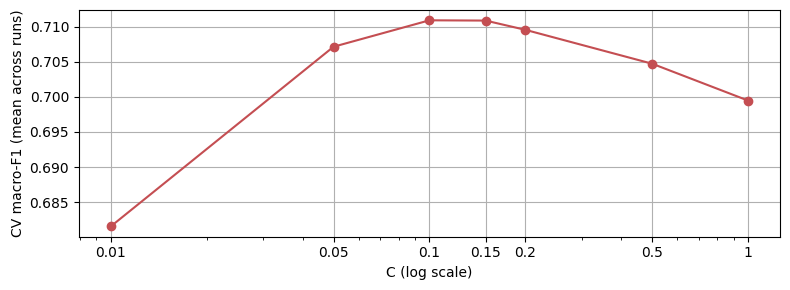

In [32]:
run1 = {'mean_fit_time': np.array([3266.84610605, 5141.92076564, 5904.57943288]),
 'std_fit_time': np.array([362.09008668, 175.74949523, 169.13478458]),
 'mean_score_time': np.array([37.37957104, 20.38381728, 13.61957614]),
 'std_score_time': np.array([5.01019908, 2.7447093 , 0.93486016]),
 'param_model__C': np.ma.masked_array(data=[0.1, 0.5, 1.0],
              mask=[False, False, False],
        fill_value=1e+20),
 'params': [{'model__C': 0.1}, {'model__C': 0.5}, {'model__C': 1}],
 'split0_test_score': np.array([0.71227575, 0.70234937, 0.69698505]),
 'split1_test_score': np.array([0.71097103, 0.70743306, 0.70264608]),
 'split2_test_score': np.array([0.70951092, 0.70439981, 0.69878481]),
 'mean_test_score': np.array([0.71091923, 0.70472741, 0.69947198]),
 'std_test_score': np.array([0.00112933, 0.00208829, 0.00236163]),
 'rank_test_score': np.array([1, 2, 3])}

run2 = {'mean_fit_time': np.array([1672.90899626, 3650.03811455, 4631.62400015, 4903.0905358 ,
        5050.2220161 ]),
 'std_fit_time': np.array([116.64378966, 188.70409201, 262.50671058, 229.9060881 ,
         88.74921293]),
 'mean_score_time': np.array([65.08517901, 49.62144335, 29.14701962, 20.77684689, 16.26441979]),
 'std_score_time': np.array([4.18956176, 3.12205407, 8.29387768, 7.37942695, 4.25184832]),
 'param_model__C': np.ma.masked_array(data=[0.01, 0.05, 0.1, 0.15, 0.2],
              mask=[False, False, False, False, False],
        fill_value=1e+20),
 'params': [{'model__C': 0.01},
  {'model__C': 0.05},
  {'model__C': 0.1},
  {'model__C': 0.15},
  {'model__C': 0.2}],
 'split0_test_score': np.array([0.68469962, 0.7096963 , 0.71227575, 0.71146508, 0.70970713]),
 'split1_test_score': np.array([0.68162034, 0.70758092, 0.71097103, 0.71218031, 0.71049445]),
 'split2_test_score': np.array([0.67826975, 0.70416723, 0.70951092, 0.70899429, 0.70848149]),
 'mean_test_score': np.array([0.6815299 , 0.70714815, 0.71091923, 0.71087989, 0.70956103]),
 'std_test_score': np.array([0.00262576, 0.00227788, 0.00112933, 0.00136492, 0.00082826]),
 'rank_test_score': np.array([5, 4, 1, 2, 3])}

def to_df(cv_dict, run_id):
    df = pd.DataFrame({
        "C": np.array(cv_dict["param_model__C"], dtype=float),
        "mean_test_score": cv_dict["mean_test_score"],
        "std_test_score": cv_dict["std_test_score"],
        "run": run_id
    })
    return df

df_all = pd.concat([to_df(run1, "run1"), to_df(run2, "run2")], ignore_index=True)

agg = (df_all.groupby("C", as_index=False).agg(mean_f1=("mean_test_score", "mean"), std_over_runs=("mean_test_score", "std"), n=("mean_test_score", "size")).sort_values("C"))

x = agg["C"].values
y = agg["mean_f1"].values

plt.figure(figsize=(8,3))
plt.plot(x, y, marker="o", color="#C44E52")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("CV macro-F1 (mean across runs)")
ticks = np.sort(x)
plt.xticks(ticks, [f"{t:g}" for t in ticks], rotation=0)
plt.gca().set_axisbelow(True)
plt.grid(axis="y")
plt.grid(axis="x")
plt.tight_layout()
#plt.savefig("linearsvc_f1_vs_C.pdf", bbox_inches="tight")

## C) SGDClassifier (baseline)

As a supplementary reference and a baseline to compare the performances of the main models, I also used SGDClassifier. SGD is an approximate linear SVM trained via stochastic gradient descent, which scales really well on TF-IDF and large datasets.

In [ ]:
# Same preprocessor setup of LinearSVC

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

num_cols = ["page_rank","year","month","dayofweek","hour","ts_missing","title_wc","article_wc"]

text_features = FeatureUnion([
    ("word", TfidfVectorizer(
        stop_words="english",
        ngram_range=(1,2),
        min_df=2,
        max_df=0.9,
        sublinear_tf=True
    )),
    ("char", TfidfVectorizer(
        analyzer="char",
        ngram_range=(3,5),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    ))
])

preprocessor = ColumnTransformer([
    ("text", text_features, "text"),
    ("num", StandardScaler(with_mean=False), num_cols)
])

### Hyperparameter tuning

For the SGD-based classifier, tuning was limited to `hinge` and `log_loss` functions (that emulate the behaviour of Logistic Regression and LinearSVC) + `alpha`.

In [39]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

pipe_sgd = Pipeline(
    steps=[("preprocessor", preprocessor),
    ("model", sgd)], memory=cachedir
)

In [40]:
# Run 1

In [41]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid_sgd = {
    "model__alpha": [1e-4, 5e-4, 1e-3, 5e-3],
    "model__loss": ["hinge", "log_loss"]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_sgd = GridSearchCV(
    pipe_sgd,
    param_grid_sgd,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_sgd.fit(X, y)
print("Best SGD params:", grid_sgd.best_params_)
print("Best SGD f1_macro:", grid_sgd.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best SGD params: {'model__alpha': 0.0001, 'model__loss': 'log_loss'}
Best SGD f1_macro: 0.6610903752101853


In [44]:
grid_sgd.cv_results_

{'mean_fit_time': array([427.76002765, 320.48476235, 300.22616593, 220.21099528,
        246.92760833, 149.70161057,  97.41154345,  68.36934582]),
 'std_fit_time': array([ 0.51069261, 10.68205858,  8.76772486, 10.92636919,  9.56577682,
        41.38794279,  1.45346962, 11.30787274]),
 'mean_score_time': array([12.99676569, 63.66923761, 63.92323693, 65.77968915, 65.89162032,
        39.86721651, 26.70422832, 23.70605206]),
 'std_score_time': array([ 0.17064567,  4.40740974,  0.67112899,  1.24023308,  1.52302091,
        16.80230761,  1.61328845,  3.98863214]),
 'param_model__alpha': masked_array(data=[0.0001, 0.0001, 0.0005, 0.0005, 0.001, 0.001, 0.005,
                    0.005],
              mask=[False, False, False, False, False, False, False, False],
        fill_value=1e+20),
 'param_model__loss': masked_array(data=['hinge', 'log_loss', 'hinge', 'log_loss', 'hinge',
                    'log_loss', 'hinge', 'log_loss'],
              mask=[False, False, False, False, False, False,

In [ ]:
# Run 2

In [45]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid_sgd = {
    "model__alpha": [1e-6, 5e-6, 1e-5, 5e-5, 1e-4],
    "model__loss": ["hinge", "log_loss"]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_sgd = GridSearchCV(
    pipe_sgd,
    param_grid_sgd,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_sgd.fit(X, y)
print("Best SGD params:", grid_sgd.best_params_)
print("Best SGD f1_macro:", grid_sgd.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best SGD params: {'model__alpha': 1e-05, 'model__loss': 'hinge'}
Best SGD f1_macro: 0.688807805216344


In [46]:
grid_sgd.cv_results_

{'mean_fit_time': array([1606.90004484, 1766.50874329, 1392.026045  , 1177.17206645,
        1341.54806455,  848.86359644,  672.11640104,  461.82712213,
         451.69517883,  238.37692602]),
 'std_fit_time': array([27.60883911,  4.80173506, 31.08038174, 15.47667332, 16.64304004,
        61.08725404, 43.42713349, 16.60932541, 72.07636705, 49.0513513 ]),
 'mean_score_time': array([86.69604667, 77.48458354, 73.6794099 , 67.4922742 , 67.8802464 ,
        51.67339722, 29.99234422, 56.4033912 , 15.84598931, 20.24426524]),
 'std_score_time': array([ 3.28012508,  4.01067846,  4.66766291,  1.01228571,  1.19727975,
        23.15102777, 10.20140418,  2.19067076,  2.8987214 ,  6.1605371 ]),
 'param_model__alpha': masked_array(data=[1e-06, 1e-06, 5e-06, 5e-06, 1e-05, 1e-05, 5e-05, 5e-05,
                    0.0001, 0.0001],
              mask=[False, False, False, False, False, False, False, False,
                    False, False],
        fill_value=1e+20),
 'param_model__loss': masked_array(da

No more changes, so the best configuration is found for `alpha = 1e-05` and `loss = 'hinge'`.

## D) Naive Solution with Random Guessing

In [27]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

dummy = DummyClassifier(strategy="stratified", random_state=42)

score = cross_val_score(dummy, X, y, scoring="f1_macro", cv=cv).mean()
print("Macro-F1:", score)

Macro-F1: 0.14171426787233446


## Setting up the models for intermediate predictions

In [43]:
# Logistic Regression predictions (1)

best_model_log = grid_log.best_estimator_
y_pred_log = best_model_log.predict(X_eval)

In [27]:
# LinearSVC (2)

best_model_svm = grid_svm.best_estimator_
y_pred_svm = best_model_svm.predict(X_eval)

In [47]:
# SGDClassifier (3)

best_model_sgd = grid_sgd.best_estimator_
y_pred_sgd = best_model_sgd.predict(X_eval)

In [ ]:
# Dummy Classifier (naive)

dummy.fit(X, y)
y_pred_dummy = dummy.predict(X_eval)

In [44]:
df_log = pd.DataFrame({
    "Id" : range(len(y_pred_log)),
    "Predicted" : y_pred_log
})

In [28]:
df_svm = pd.DataFrame({
    "Id" : range(len(y_pred_svm)),
    "Predicted" : y_pred_svm
})

In [48]:
df_sgd = pd.DataFrame({
    "Id" : range(len(y_pred_sgd)),
    "Predicted" : y_pred_sgd
})

In [ ]:
df_dummy = pd.DataFrame({
    "Id" : range(len(y_pred_dummy)),
    "Predicted" : y_pred_dummy
})

In [ ]:
# Saving

In [45]:
df_log.to_csv("submission_log.csv", index=False)  # LogReg --> 0.728 on the public leaderboard with reproducibility

In [29]:
df_svm.to_csv("submission_svm.csv", index=False)  # LinearSVC --> 0.735 on the public leaderboard with reproducibility

In [49]:
df_sgd.to_csv("submission_sgd.csv", index=False)  # SGDClassifier  --> 0.698 on the public leaderboard with reproducibility

In [ ]:
df_dummy.to_csv("submission_dummy.csv", index=False) # Naive solution --> 0.150 on the public leaderboard with reproducibility

# 4) Models for final submission: LinearSVC (best) + Logistic Regression

Using the best hyperparameters found during cross-validation, the final LinearSVC and Logistic Regression pipeline is retrained on the full development set and used to generate predictions for the evaluation set.
This step is provided in order to produce the final submission files.

In [ ]:
## LinearSVC

In [56]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

num_cols = ["page_rank","year","month","dayofweek","hour","ts_missing","title_wc","article_wc"]

text_features = FeatureUnion([
    ("word", TfidfVectorizer(
        stop_words="english",
        ngram_range=(1,2),
        min_df=2,
        max_df=0.9,
        sublinear_tf=True
    )),
    ("char", TfidfVectorizer(
        analyzer="char",
        ngram_range=(3,5),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    ))
])

preprocessor = ColumnTransformer([
    ("text", text_features, "text"),
    ("num", StandardScaler(with_mean=False), num_cols)
])

In [57]:
from sklearn.svm import LinearSVC

final_svm = LinearSVC(
    C=0.1,
    class_weight="balanced",
    max_iter=200000,
    random_state=42
)

final_pipe_svm = Pipeline(
    steps=[("preprocessor", preprocessor),
           ("model", final_svm)]
)

final_pipe_svm.fit(X, y)

y_pred_svm = final_pipe_svm.predict(X_eval)

In [59]:
submission_svm = pd.DataFrame({
    "Id": range(len(y_pred_svm)),
    "Predicted": y_pred_svm
})

submission_svm.to_csv("submission1.csv", index=False)

In [ ]:
## Logistic Regression

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

num_cols = ["page_rank","year","month","dayofweek","hour","ts_missing","title_wc","article_wc"]
text_col = "text"

preprocessor = ColumnTransformer(
    transformers=[
        ("text",
         TfidfVectorizer(
             ngram_range=(1,2),
             min_df=2,
             max_df=0.9,
             stop_words="english",
             sublinear_tf=True
         ), text_col),
        ("num", StandardScaler(with_mean=False), num_cols) 
])

In [26]:
from sklearn.linear_model import LogisticRegression

final_log = LogisticRegression(
    C=2,
    solver="saga",
    max_iter=10000,
    class_weight="balanced",
    random_state=42
)

final_pipe_log = Pipeline(
    steps=[("preprocessor", preprocessor),
    ("model", final_log)]
)

final_pipe_log.fit(X, y)

y_pred_log = final_pipe_log.predict(X_eval)

In [27]:
submission_log = pd.DataFrame({
    "Id": range(len(y_pred_log)),
    "Predicted": y_pred_log
})

submission_log.to_csv("submission2.csv", index=False)